# Tiền xử lý NLP cho Tweet (Airline Sentiment)

Dataset: [twitter-airline-sentiment](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment) - phân tích cảm xúc tweet về các hãng hàng không Mỹ (2015).

Pipeline:
1. **RegEx**: gỡ `@mention`, `#hashtag`, URL, emoji (và một số biểu tượng dạng text).
2. **Chuẩn hóa**: giải mã HTML entity, chữ thường.
3. **Stop words** tiếng Anh + **Lemmatization** (WordNet).

### Import thư viện

In [1]:
import warnings
warnings.filterwarnings("ignore")
import re
import html

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from collections import Counter

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize
import contractions
import emoji

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

### Download packages NLTK

In [2]:
def _ensure_nltk(pkg: str) -> None:
    try:
        if pkg == "stopwords":
            nltk.data.find("corpora/stopwords")
        elif pkg == "wordnet":
            nltk.data.find("corpora/wordnet")
        elif pkg in ("punkt", "punkt_tab"):
            nltk.data.find(f"tokenizers/{pkg}")
        else:
            nltk.data.find(f"taggers/{pkg}")
    except LookupError:
        nltk.download(pkg)


for _p in ("punkt_tab", "punkt", "stopwords", "wordnet", "averaged_perceptron_tagger_eng", "averaged_perceptron_tagger"):
    _ensure_nltk(_p)

try:
    word_tokenize("ping")
except LookupError:
    nltk.download("punkt")
    nltk.download("punkt_tab")

STOP = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hugdo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [64]:
STOP

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [65]:
negation_words = {"not", "no", "nor", "none", "neither", "never"}
# 3. Tạo một tập STOPWORDS ĐÃ TỐI ƯU CHO AI (Lấy rổ tổng trừ đi các từ cần cứu)
STOP = STOP - negation_words


In [66]:
STOP

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 

## 1. Đọc dữ liệu

In [36]:
ROOT = Path("..").resolve()
CSV_PATH = ROOT / "data" / "Tweets.csv"

df = pd.read_csv(CSV_PATH, encoding="utf-8")
print(df.shape)
print(df.columns)
df[["airline_sentiment", "airline", "text"]]

(14640, 15)
Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')


,airline_sentiment,airline,text
0,neutral,Virgin America,@VirginAmerica What @dhepburn said.
1,positive,Virgin America,@VirginAmerica plus you've added commercials t...
2,neutral,Virgin America,@VirginAmerica I didn't today... Must mean I n...
3,negative,Virgin America,@VirginAmerica it's really aggressive to blast...
4,negative,Virgin America,@VirginAmerica and it's a really big bad thing...
...,...,...,...
14635,positive,American,@AmericanAir thank you we got on a different f...
14636,negative,American,@AmericanAir leaving over 20 minutes Late Flig...
14637,neutral,American,@AmericanAir Please bring American Airlines to...
14638,negative,American,"@AmericanAir you have my money, you change my ..."


### Thông tin cơ bản về Dataset

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  str    
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   str    
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  str    
 6   airline_sentiment_gold        40 non-null     str    
 7   name                          14640 non-null  str    
 8   negativereason_gold           32 non-null     str    
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  str    
 11  tweet_coord                   1019 non-null   str    
 12  tweet_created                 14640 non-null  str    
 13  tweet_locati

In [16]:
print(df['airline_sentiment'].value_counts())


airline_sentiment
negative    9159
neutral     3091
positive    2354
Name: count, dtype: int64


In [22]:
df['airline'].value_counts()

airline
United            3822
US Airways        2913
American          2723
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

### Kiểm tra Duplicates

In [44]:
print(f"Tổng số dòng: {len(df):,}")
print(f"Số dòng duplicate (toàn bộ): {df.duplicated().sum():,}")
print(f"Số dòng duplicate (chỉ text): {df.duplicated(subset=['text']).sum():,}")

Tổng số dòng: 14,640
Số dòng duplicate (toàn bộ): 36
Số dòng duplicate (chỉ text): 213


## 2. Làm sạch bằng Regular Expression

- **URL**: `http(s)://...`, `www....`, rút gọn `t.co/...`
- **@mention**: `@handle`
- **#hashtag**: `#tag`
- **Emoji**: các khối Unicode phổ biến + emoticon kiểu `:-)` `:D`

Sau đó **html.unescape** để xử lý `&amp;`, `&lt;`, v.v.

In [52]:
from wordsegment import load, segment
load()
print(segment("Hello i do not like worstflightever enraged_face 😡")) 
# Kết quả: ['worst', 'flight', 'ever'] -> Model sẽ học được chữ 'worst'!


['hello', 'i', 'do', 'not', 'like', 'worst', 'flight', 'ever', 'enraged', 'face']


In [55]:
import re
from wordsegment import segment

# 1. Định nghĩa hàm xử lý riêng cho các cụm bắt được
def process_hashtag(match):
    # Lấy toàn bộ cụm hashtag bắt được (VD: r"#worstflightever")
    hashtag_text = match.group(0) 
    
    # Bỏ dấu '#' ở đầu đi để lấy phần chữ (VD: "worstflightever")
    clean_text = hashtag_text.replace('#', '') 
    
    # Gọi hàm segment trên phần chữ (Hàm trả về 1 list: ['worst', 'flight', 'ever'])
    segmented_list = segment(clean_text)
    
    # Nối lại bằng khoảng trắng và trả về chuỗi thay thế
    return " " + " ".join(segmented_list) + " "


# 2. Áp dụng vào văn bản
text = "The food is so dry #worstflightever 😡"

# Truyền trực tiếp hàm `process_hashtag` vào re.sub
# Lúc này Regex chỉ tìm dấu #, tìm được thì bốc cái chữ quăng vào hàm segment, còn lại giữ nguyên
RE_HASHTAG = re.compile(r"#\w+")

text = RE_HASHTAG.sub(process_hashtag, text)

print(text)


The food is so dry  worst flight ever  😡


In [56]:
contractions.fix("don't") # "don't" -> "do not"

'do not'

In [57]:
emoji.demojize("😡 💯") # "😡" -> ":enraged_face:"

':enraged_face: :hundred_points:'

In [61]:
# Regex
RE_URL = re.compile(
    r"https?://\S+|www\.\S+", re.IGNORECASE
)
RE_MENTION = re.compile(r"@\w+")
RE_HASHTAG = re.compile(r"#\w+")

# Emoji => lấy theo dải mã Unicode
RE_EMOJI = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002702-\U000027B0"  # Dingbats
    "\U000024C2-\U0001F251"  # Supplemental
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U0001FA70-\U0001FAFF"  # symbols extended-A
    "]+",
    flags=re.UNICODE,
)

# Text emoticon dạng ký tự: =))); :);...
RE_TEXT_EMOTICONS = re.compile(
    r"(?::|;|=)(?:[-']?)(?:\)|\(|D|P|S|\\|/|\[|\]|\||\^|o|O|3|>|<|x|X)(?![\w])"
    r"|(?:\^_|\^_\^|>\.<|T_T|\\o/)",
    re.IGNORECASE,
)

RE_NUMBERS = re.compile(r'\d+')
RE_SPECIAL_CHARS = re.compile(r"[^a-zA-Z\s_]")
RE_ELONGATED = re.compile(r'(.)\1+')
RE_MULTI_SPACE = re.compile(r"\s+")


def clean_text_regex(raw: str) -> str:
    """Loại URL, mention, hashtag, emoji bằng RegEx; chuẩn hóa khoảng trắng."""
    if not isinstance(raw, str) or not raw.strip():
        return ""
    
    t = html.unescape(raw)
    t = RE_URL.sub(" ", t)
    t = RE_MENTION.sub(" ", t)
    t = contractions.fix(t) # "don't" -> "do not"
    t = RE_HASHTAG.sub(process_hashtag, t)
    t = emoji.demojize(t) # "😡" -> ":enraged_face:"
    t = RE_SPECIAL_CHARS.sub(" ", t)
    t = RE_ELONGATED.sub(r'\1\1', t)
    t = RE_MULTI_SPACE.sub(" ", t).lower().strip()
    return t

In [62]:
samples = df["text"].dropna().head(8).tolist()
for s in samples:
    print("---")
    print("Gốc:  ", s[:120], "..." if len(s) > 120 else "")
    print("Sạch: ", clean_text_regex(s)[:120], "..." if len(clean_text_regex(s)) > 120 else "")

---
Gốc:   @VirginAmerica What @dhepburn said. 
Sạch:  what said 
---
Gốc:   @VirginAmerica plus you've added commercials to the experience... tacky. 
Sạch:  plus you have added commercials to the experience tacky 
---
Gốc:   @VirginAmerica I didn't today... Must mean I need to take another trip! 
Sạch:  i did not today must mean i need to take another trip 
---
Gốc:   @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little re ...
Sạch:  it is really aggressive to blast obnoxious entertainment in your guests faces they have little recourse 
---
Gốc:   @VirginAmerica and it's a really big bad thing about it 
Sạch:  and it is a really big bad thing about it 
---
Gốc:   @VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.
it's really the only bad thing ...
Sạch:  seriously would pay a flight for seats that did not have this playing it is really the only bad thing about flying va 
---
Gốc:   @

## 3. Tokenize, bỏ stop words, lemmatize

Ánh xạ POS (Penn Treebank => WordNet) để lemmatize động từ/tính từ chính xác hơn.

In [69]:
def treebank_to_wordnet(tag: str):
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


def preprocess_pipeline(text: str) -> str:
    """RegEx > token > lower > bỏ stopword > lemma > chuỗi kết quả."""
    cleaned = clean_text_regex(text)
    if not cleaned:
        return ""
    tokens = word_tokenize(cleaned)
    # Chỉ giữ token chữ thuần túy để giảm nhiễu tweet (bỏ số, ký tự đặc biệt, URL đã gỡ)
    # Ví dụ: giữ "flight", bỏ "A321" hoặc "100"; nếu cần giữ từ ngữ chứa apostrophe, hãy mở rộng regex.
   
    tagged = pos_tag(tokens)
    lemmas = [
        LEMMATIZER.lemmatize(w, treebank_to_wordnet(tag)) for w, tag in tagged
    ]
    
    final_tokens = [w for w in lemmas if w not in STOP and len(w) > 1]
    return " ".join(lemmas)

In [70]:
df["text_cleaned"] = df["text"].astype(str).map(clean_text_regex)
df["text_preprocessed"] = df["text"].astype(str).map(preprocess_pipeline)

compare = df[["text", "text_cleaned", "text_preprocessed"]].head(12)
compare

,text,text_cleaned,text_preprocessed
0,@VirginAmerica What @dhepburn said.,what said,what say
1,@VirginAmerica plus you've added commercials t...,plus you have added commercials to the experie...,plus you have add commercial to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i did not today must mean i need to take anoth...,i do not today must mean i need to take anothe...
3,@VirginAmerica it's really aggressive to blast...,it is really aggressive to blast obnoxious ent...,it be really aggressive to blast obnoxious ent...
4,@VirginAmerica and it's a really big bad thing...,and it is a really big bad thing about it,and it be a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay a flight for seats that di...,seriously would pay a flight for seat that do ...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this ear worm w...,yes nearly every time i fly vx this ear worm w...
7,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men with...,really miss a prime opportunity for men withou...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well i did not but now i do d,well i do not but now i do d
9,"@VirginAmerica it was amazing, and arrived an ...",it was amazing and arrived an hour early you a...,it be amaze and arrive an hour early you be to...


In [71]:
# Save
out = ROOT / "data" / "Tweets_preprocessed.csv"
df.to_csv(out, index=False, encoding="utf-8")
print("Save to:", out)

Save to: D:\hungdo\Airline-Sentiment\data\Tweets_preprocessed.csv


In [74]:
X = df['text_preprocessed']
y = df['airline_sentiment']

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [77]:
tfid = TfidfVectorizer(ngram_range=(1, 2))
tfid


,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

### Huấn luyện mô hình trước khi xử lý mất cân bằng

In [91]:
X_train_idf = tfid.fit_transform(X_train)
X_test_idf = tfid.transform(X_test)

print(f"Training set size: {X_train_idf.shape[0]}")
print(f"Test set size: {X_test_idf.shape[0]}")
print(f"TF-IDF train shape: {X_train_idf.shape}")
print(f"TF-IDF test shape: {X_test_idf.shape}")
print("\nPhân bố nhãn trong training set:")
print(pd.Series(y_train).value_counts().sort_index())


Training set size: 11712
Test set size: 2928
TF-IDF train shape: (11712, 74399)
TF-IDF test shape: (2928, 74399)

Phân bố nhãn trong training set:
airline_sentiment
negative    7343
neutral     2479
positive    1890
Name: count, dtype: int64


In [86]:
sentiment_order = ["negative", "neutral", "positive"]

In [131]:
# Train Random Forest 
rf_original = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_original.fit(X_train_idf, y_train)

# Predict và tính F1 score
y_pred_rf = rf_original.predict(X_test_idf)
f1_rf_original = f1_score(y_pred_rf, y_test, average='macro')

print(f"Random Forest (nguyên bản) - Macro F1 Score: {f1_rf_original:.4f}")
print(classification_report(y_test, y_pred_rf, 
                           target_names=sentiment_order))

Random Forest (nguyên bản) - Macro F1 Score: 0.7335
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      1835
     neutral       0.61      0.68      0.64       620
    positive       0.72      0.68      0.70       473

    accuracy                           0.79      2928
   macro avg       0.73      0.74      0.73      2928
weighted avg       0.79      0.79      0.79      2928



In [93]:
# Train Logistic Regression (nguyên bản)
lr_original = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)
lr_original.fit(X_train_idf, y_train)

# Predict và tính F1 score
y_pred_lr = lr_original.predict(X_test_idf)
f1_lr_original = f1_score(y_pred_lr, y_test, average='macro')

print(f"Logistic Regression (nguyên bản) - Macro F1 Score: {f1_lr_original:.4f}")
print(classification_report(y_test, y_pred_lr, 
                           target_names=sentiment_order))

Logistic Regression (nguyên bản) - Macro F1 Score: 0.7579
              precision    recall  f1-score   support

    negative       0.89      0.89      0.89      1835
     neutral       0.65      0.69      0.67       620
    positive       0.74      0.69      0.72       473

    accuracy                           0.81      2928
   macro avg       0.76      0.76      0.76      2928
weighted avg       0.81      0.81      0.81      2928



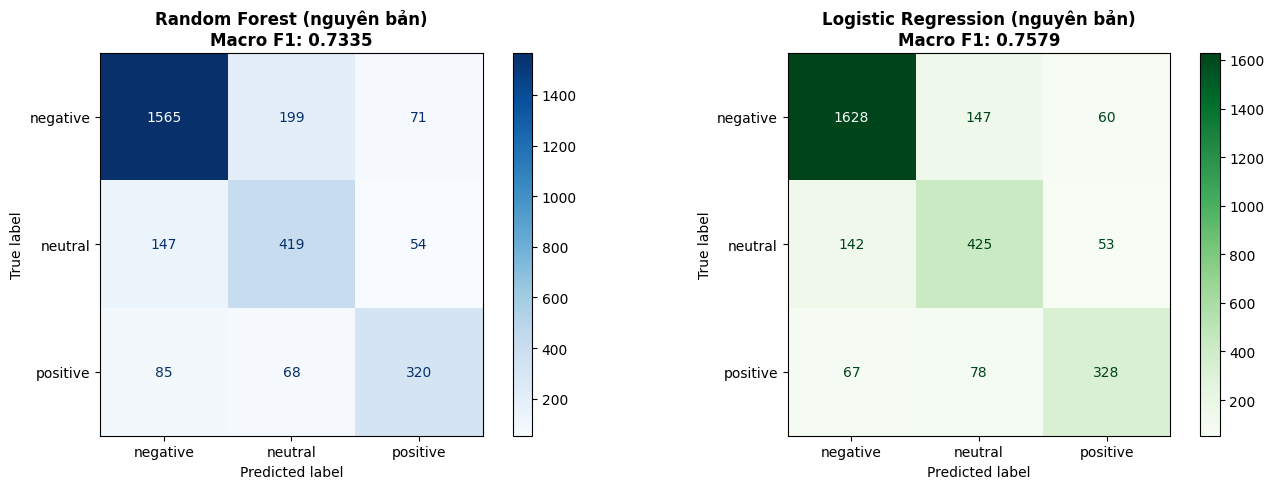

In [94]:
# Confusion Matrices (nguyên bản)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf_orig = confusion_matrix(y_test, y_pred_rf, labels=sentiment_order)
disp_rf_orig = ConfusionMatrixDisplay(confusion_matrix=cm_rf_orig, display_labels=sentiment_order)
disp_rf_orig.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title(f"Random Forest (nguyên bản)\nMacro F1: {f1_rf_original:.4f}", fontweight='bold')

# Logistic Regression
cm_lr_orig = confusion_matrix(y_test, y_pred_lr, labels=sentiment_order)
disp_lr_orig = ConfusionMatrixDisplay(confusion_matrix=cm_lr_orig, display_labels=sentiment_order)
disp_lr_orig.plot(cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title(f"Logistic Regression (nguyên bản)\nMacro F1: {f1_lr_original:.4f}", fontweight='bold')

plt.tight_layout()
plt.show()

### Huấn luyện mô hình sau khi xử lý cân bằng bằng `RandomOver-sampling` 

In [95]:
# Oversampling chỉ trên tập train
ros = RandomOverSampler(
    sampling_strategy='auto',
    random_state=42
)

X_train_ros, y_train_ros = ros.fit_resample(X_train_idf, y_train)
X_test_ros, y_test_ros = X_test_idf, y_test

print("Phân bố nhãn sau oversampling:")
print(pd.Series(y_train_ros).value_counts().sort_index())


Phân bố nhãn sau oversampling:
airline_sentiment
negative    7343
neutral     7343
positive    7343
Name: count, dtype: int64


In [98]:
# Train Random Forest (SAU RandomOver-sampling)
rf_ros = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf_ros.fit(X_train_ros, y_train_ros)

# Predict và tính F1 score
y_pred_rf_ros = rf_ros.predict(X_test_ros)
macro_f1_score_random_forest_over = f1_score(y_pred_rf_ros, y_test_ros, average='macro')

print(f"Random Forest (Sau RandomOver-sampling) - Macro F1 Score: {macro_f1_score_random_forest_over:.4f}")
print(classification_report(y_test_ros, y_pred_rf_ros, 
                           target_names=sentiment_order))

Random Forest (Sau RandomOver-sampling) - Macro F1 Score: 0.7238
              precision    recall  f1-score   support

    negative       0.84      0.90      0.87      1835
     neutral       0.65      0.61      0.63       620
    positive       0.75      0.61      0.67       473

    accuracy                           0.79      2928
   macro avg       0.75      0.71      0.72      2928
weighted avg       0.79      0.79      0.79      2928



In [99]:
# Train Logistic Regression (SAU RandomOver-sampling)
lr_ros = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)
lr_ros.fit(X_train_ros, y_train_ros)

# Predict và tính F1 score
y_pred_lr_ros = lr_ros.predict(X_test_ros)
macro_f1_score_logistic_regression_over = f1_score(y_pred_lr_ros, y_test_ros, average='macro')

print(f"Logistic Regression (Sau RandomOver-sampling) - Macro F1 Score: {macro_f1_score_logistic_regression_over:.4f}")
print(classification_report(y_test_ros, y_pred_lr_ros, 
                           target_names=sentiment_order))

Logistic Regression (Sau RandomOver-sampling) - Macro F1 Score: 0.7576
              precision    recall  f1-score   support

    negative       0.88      0.90      0.89      1835
     neutral       0.67      0.66      0.67       620
    positive       0.75      0.69      0.72       473

    accuracy                           0.82      2928
   macro avg       0.77      0.75      0.76      2928
weighted avg       0.81      0.82      0.81      2928



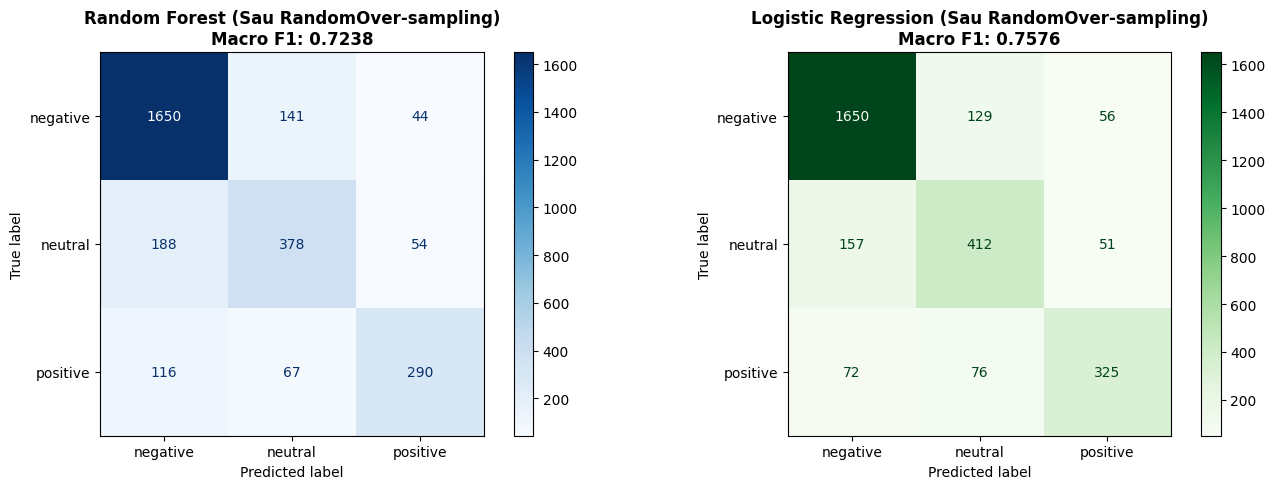

In [100]:
# Confusion Matrices (SAU RandomOver-sampling)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf = confusion_matrix(y_test_ros, y_pred_rf_ros, labels=sentiment_order)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=sentiment_order)
disp_rf.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title(f"Random Forest (Sau RandomOver-sampling)\nMacro F1: {macro_f1_score_random_forest_over:.4f}", fontweight='bold')

# Logistic Regression
cm_lr = confusion_matrix(y_test_ros, y_pred_lr_ros, labels=sentiment_order)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=sentiment_order)
disp_lr.plot(cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title(f"Logistic Regression (Sau RandomOver-sampling)\nMacro F1: {macro_f1_score_logistic_regression_over:.4f}", fontweight='bold')

plt.tight_layout()
plt.show()

### Huấn luyện mô hình sau khi xử lý cân bằng bằng `under-sampling`

In [101]:
under_sampling = RandomUnderSampler(
    sampling_strategy='auto',
    random_state=42,
    replacement=False
)

X_train_under, y_train_under = under_sampling.fit_resample(X_train_idf, y_train)
X_test_under, y_test_under = X_test_idf, y_test

print("Phân bố nhãn sau undersampling:")
print(pd.Series(y_train_under).value_counts().sort_index())


Phân bố nhãn sau undersampling:
airline_sentiment
negative    1890
neutral     1890
positive    1890
Name: count, dtype: int64


In [103]:
random_forest_classifier_under = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
random_forest_classifier_under.fit(X_train_under, y_train_under)

random_forest_classifier_under_prediction = random_forest_classifier_under.predict(X_test_under)
macro_f1_score_random_forest_under = f1_score(random_forest_classifier_under_prediction, y_test_under, average='macro')
print(f"Random Forest (Sau Under-sampling) - Macro F1 Score: {macro_f1_score_random_forest_under:.4f}")
print(classification_report(y_test_under, random_forest_classifier_under_prediction))

Random Forest (Sau Under-sampling) - Macro F1 Score: 0.7179
              precision    recall  f1-score   support

    negative       0.89      0.79      0.84      1835
     neutral       0.57      0.71      0.63       620
    positive       0.65      0.71      0.68       473

    accuracy                           0.76      2928
   macro avg       0.70      0.74      0.72      2928
weighted avg       0.78      0.76      0.77      2928



In [104]:
logistic_regression_under = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)
logistic_regression_under.fit(X_train_under, y_train_under)

logistic_regression_under_prediction = logistic_regression_under.predict(X_test_under)
macro_f1_score_logistic_regression_under = f1_score(logistic_regression_under_prediction, y_test_under, average='macro')
print(f"Logistic Regression (Sau Under-sampling) - Macro F1 Score: {macro_f1_score_logistic_regression_under:.4f}")
print(classification_report(y_test_under, logistic_regression_under_prediction))

Logistic Regression (Sau Under-sampling) - Macro F1 Score: 0.7385
              precision    recall  f1-score   support

    negative       0.90      0.83      0.86      1835
     neutral       0.60      0.70      0.64       620
    positive       0.69      0.73      0.71       473

    accuracy                           0.79      2928
   macro avg       0.73      0.75      0.74      2928
weighted avg       0.80      0.79      0.79      2928



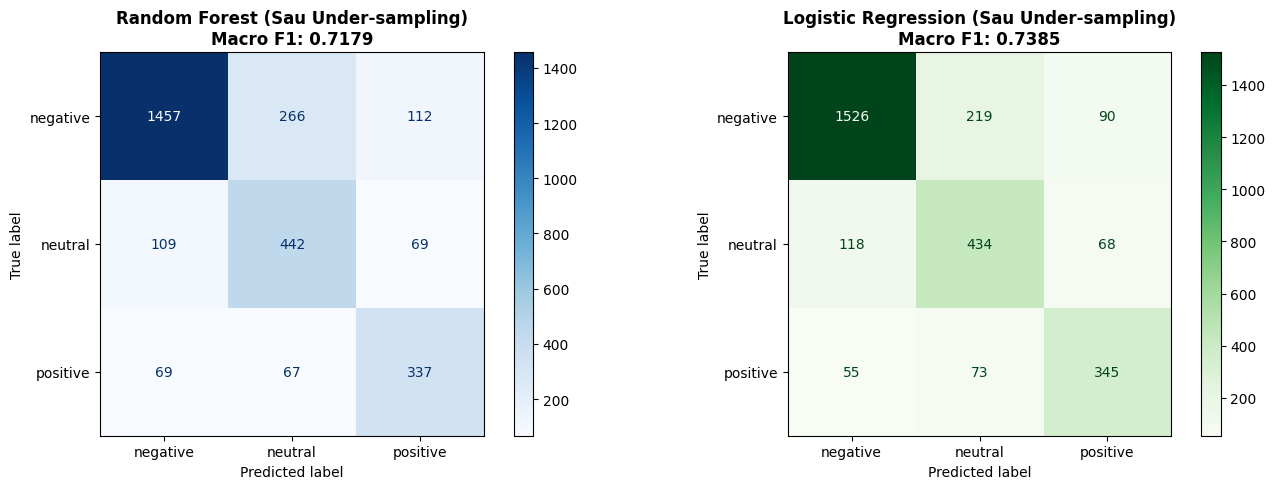

In [105]:
# Confusion Matrices (SAU Under-sampling)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Random Forest
cm_rf_under = confusion_matrix(y_test_under, random_forest_classifier_under_prediction, labels=sentiment_order)
disp_rf_under = ConfusionMatrixDisplay(confusion_matrix=cm_rf_under, display_labels=sentiment_order)
disp_rf_under.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title(f"Random Forest (Sau Under-sampling)\nMacro F1: {macro_f1_score_random_forest_under:.4f}", fontweight='bold')
# Logistic Regression
cm_lr_under = confusion_matrix(y_test_under, logistic_regression_under_prediction, labels=sentiment_order)
disp_lr_under = ConfusionMatrixDisplay(confusion_matrix=cm_lr_under, display_labels=sentiment_order)
disp_lr_under.plot(cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title(f"Logistic Regression (Sau Under-sampling)\nMacro F1: {macro_f1_score_logistic_regression_under:.4f}", fontweight='bold')
plt.tight_layout()
plt.show()

In [106]:
# So sánh F1 Scores giữa 3 phương pháp, xem cải thiện bao nhiêu so với nguyên bản
comparison_data = {
    'Model': ['Random Forest', 'Logistic Regression'],
    'F1 (nguyên bản)': [f1_rf_original, f1_lr_original],
    'F1 (Sau Over-sampling)': [macro_f1_score_random_forest_over, macro_f1_score_logistic_regression_over],
    'F1 (Sau Under-sampling)': [macro_f1_score_random_forest_under, macro_f1_score_logistic_regression_under]
}

comparison_df = pd.DataFrame(comparison_data)
print("="*80)
print("SO SÁNH F1 SCORES GIỮA CÁC PHƯƠNG PHÁP")
print("="*80)
display(comparison_df.round(4))


SO SÁNH F1 SCORES GIỮA CÁC PHƯƠNG PHÁP


,Model,F1 (nguyên bản),F1 (Sau Over-sampling),F1 (Sau Under-sampling)
0,Random Forest,0.7335,0.7238,0.7179
1,Logistic Regression,0.7579,0.7576,0.7385


In [109]:
# Phân tích chi tiết F1-Score theo từng class
from sklearn.metrics import f1_score

# Tính F1-Score cho từng class (negative, neutral, positive) - Nguyên bản
f1_rf_per_class_orig = f1_score(y_test, y_pred_rf_original, average=None, labels=sentiment_order)
f1_lr_per_class_orig = f1_score(y_test, y_pred_lr_original, average=None, labels=sentiment_order)

# Tính F1-Score cho từng class (negative, neutral, positive) - Sau Over-sampling
f1_rf_per_class_over = f1_score(y_test_ros, y_pred_rf_ros, average=None, labels=sentiment_order)
f1_lr_per_class_over = f1_score(y_test_ros, y_pred_lr_ros, average=None, labels=sentiment_order)

# Tính F1-Score cho từng class (negative, neutral, positive) - Sau Under-sampling
f1_rf_per_class_under = f1_score(y_test_under, random_forest_classifier_under_prediction, average=None, labels=sentiment_order)
f1_lr_per_class_under = f1_score(y_test_under, logistic_regression_under_prediction, average=None, labels=sentiment_order)

# Tạo DataFrame để so sánh F1-Score theo từng class giữa 3 phương pháp
f1_comparison_df = pd.DataFrame({
    'Sentiment': sentiment_order,
    'F1 (Original) - RF': f1_rf_per_class_orig,
    'F1 (Original) - LR': f1_lr_per_class_orig,
    'F1 (Over-sampling) - RF': f1_rf_per_class_over,
    'F1 (Over-sampling) - LR': f1_lr_per_class_over,
    'F1 (Under-sampling) - RF': f1_rf_per_class_under,
    'F1 (Under-sampling) - LR': f1_lr_per_class_under
})  

print("="*80)
print("SO SÁNH F1-SCORE THEO TỪNG CLASS GIỮA CÁC PHƯƠNG PHÁP")
print("="*80)
display(f1_comparison_df.round(4))  



SO SÁNH F1-SCORE THEO TỪNG CLASS GIỮA CÁC PHƯƠNG PHÁP


,Sentiment,F1 (Original) - RF,F1 (Original) - LR,F1 (Over-sampling) - RF,F1 (Over-sampling) - LR,F1 (Under-sampling) - RF,F1 (Under-sampling) - LR
0,negative,0.8618,0.8867,0.8709,0.8885,0.8398,0.8636
1,neutral,0.6417,0.6693,0.6269,0.6661,0.6337,0.6449
2,positive,0.6972,0.7177,0.6736,0.7182,0.6801,0.7070


### Sử dụng GridSearchCV

In [117]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

# Tạo K-Fold cross validation để giữ nguyên tỉ lệ lớp (rất quan trọng với dữ liệu imbalanced)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 1. Tối ưu Logistic Regression
# ==========================================
print("Đang chạy GridSearchCV cho Logistic Regression...")
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga']
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid=lr_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1, # Dùng tất cả CPU core để chạy nhanh hơn
    verbose=1
)

start_time = time.time()
lr_grid.fit(X_train_idf, y_train)
print(f"Hoàn thành trong: {time.time() - start_time:.2f} giây")
print(f"Tham số LR tốt nhất: {lr_grid.best_params_}")
print(f"F1 Macro (CV) tốt nhất: {lr_grid.best_score_:.4f}\n")

# Đánh giá LR tốt nhất trên tập Test
y_pred_test = lr_grid.best_estimator_.predict(X_test_idf) 
print('Macro F1:', f1_score(y_test, y_pred_test, average='macro'))
print(classification_report(y_test, y_pred_test))


Đang chạy GridSearchCV cho Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Hoàn thành trong: 100.12 giây
Tham số LR tốt nhất: {'C': 10, 'solver': 'saga'}
F1 Macro (CV) tốt nhất: 0.7461

Macro F1: 0.7487420209250532
              precision    recall  f1-score   support

    negative       0.87      0.91      0.89      1835
     neutral       0.66      0.63      0.64       620
    positive       0.77      0.67      0.71       473

    accuracy                           0.81      2928
   macro avg       0.77      0.74      0.75      2928
weighted avg       0.81      0.81      0.81      2928



In [124]:
print("Đang chạy GridSearchCV cho Random Forest...")
rf_param_grid = {
    "n_estimators": [50, 100, 200, 300],
    'max_depth': [5, 10, 20, 30, 40],
    # 'min_samples_leaf': [1, 2, 4],
    # 'min_samples_split': [2, 5, 10],
    # 'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
rf_grid.fit(X_train_idf, y_train)
print(f"Hoàn thành trong: {time.time() - start_time:.2f} giây")
print(f"Tham số RF tốt nhất: {rf_grid.best_params_}")
print(f"F1 Macro (CV) tốt nhất: {rf_grid.best_score_:.4f}\n")

# Đánh giá RF tốt nhất trên tập Test
y_pred_test = rf_grid.best_estimator_.predict(X_test_idf) 
print('Macro F1:', f1_score(y_test, y_pred_test, average='macro'))
print(classification_report(y_test, y_pred_test))

Đang chạy GridSearchCV cho Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Hoàn thành trong: 821.67 giây
Tham số RF tốt nhất: {'max_depth': 30, 'n_estimators': 300}
F1 Macro (CV) tốt nhất: 0.7093

Macro F1: 0.7148499279146533
              precision    recall  f1-score   support

    negative       0.86      0.85      0.86      1835
     neutral       0.58      0.66      0.62       620
    positive       0.72      0.63      0.67       473

    accuracy                           0.77      2928
   macro avg       0.72      0.71      0.71      2928
weighted avg       0.78      0.77      0.78      2928



=== PHÂN TÍCH HÃNG UNITED AIRLINES ===


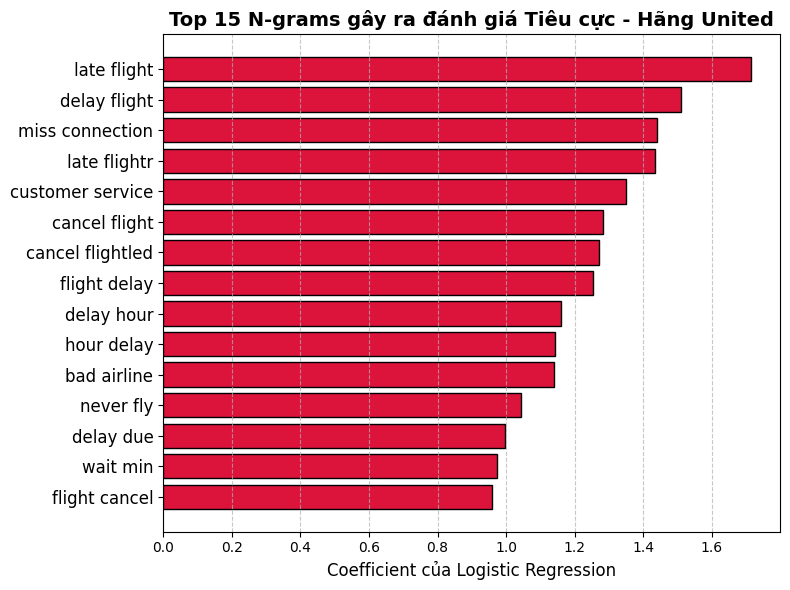

,N-gram,Coefficient
0,late flight,1.712742
1,delay flight,1.509574
2,miss connection,1.440108
3,late flightr,1.433164
4,customer service,1.349746
5,cancel flight,1.282560
6,cancel flightled,1.272148
7,flight delay,1.252957
8,delay hour,1.158890
9,hour delay,1.142423



=== PHÂN TÍCH HÃNG AMERICAN AIRLINES ===


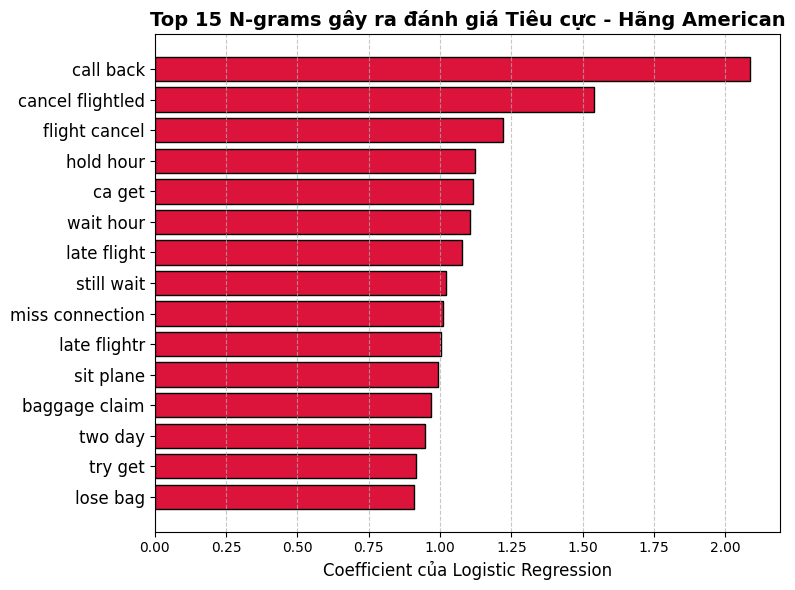

,N-gram,Coefficient
0,call back,2.086838
1,cancel flightled,1.539863
2,flight cancel,1.222156
3,hold hour,1.124082
4,ca get,1.114151
5,wait hour,1.106196
6,late flight,1.075721
7,still wait,1.021384
8,miss connection,1.009584
9,late flightr,1.003332


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_top_negative_ngrams(df, airline_name, top_n=15):
    """
    Hàm lọc dữ liệu theo hãng, dùng TF-IDF + LR để tìm và vẽ Top N-grams 
    có trọng số dự đoán Negative cao nhất.
    """
    # 1. Lọc dữ liệu của hãng cụ thể
    df_airline = df[df['airline'] == airline_name].copy()
    
    df_airline = df_airline.dropna(subset=['text_preprocessed'])
    
    # Loại bỏ các dòng text rỗng sau khi tiền xử lý
    df_airline = df_airline[df_airline['text_preprocessed'].str.strip() != '']
    
    X_text = df_airline['text_preprocessed']
    y = df_airline['airline_sentiment']
    
    # 2. Vector hóa bằng TF-IDF (ngrams 1 và 2 như yêu cầu đề bài)
    tfidf = TfidfVectorizer(ngram_range=(2, 3), max_features=5000)
    X_tfidf = tfidf.fit_transform(X_text)
    
    # 3. Huấn luyện Logistic Regression
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr.fit(X_tfidf, y)
    
    # 4. Trích xuất hệ số (Coefficient)
    # Lấy index của lớp 'negative' trong mảng lr.classes_
    neg_idx = list(lr.classes_).index('negative')
    
    # Lấy trọng số của tất cả các n-grams đối với lớp negative
    coefs = lr.coef_[neg_idx]
    feature_names = np.array(tfidf.get_feature_names_out())
    
    # Lấy ra index của top_n n-grams có trọng số ĐƯƠNG cao nhất 
    # (trọng số càng lớn, khả năng đẩy dự đoán về 'negative' càng cao)
    top_indices = coefs.argsort()[-top_n:][::-1]
    
    top_features = feature_names[top_indices]
    top_coefs = coefs[top_indices]
    
    # 5. Vẽ biểu đồ trực quan
    plt.figure(figsize=(8, 6))
    # Sắp xếp lại để vẽ thanh barh đẹp hơn (từ cao xuống thấp)
    y_pos = np.arange(len(top_features))
    plt.barh(y_pos, top_coefs[::-1], color='crimson', edgecolor='black')
    plt.yticks(y_pos, top_features[::-1], fontsize=12)
    plt.xlabel('Coefficient của Logistic Regression', fontsize=12)
    plt.title(f'Top {top_n} N-grams gây ra đánh giá Tiêu cực - Hãng {airline_name}', fontsize=14, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Trả về dataframe để in bảng nếu cần
    return pd.DataFrame({'N-gram': top_features, 'Coefficient': top_coefs})

# Khởi chạy cho United Airlines
print("=== PHÂN TÍCH HÃNG UNITED AIRLINES ===")
united_top_ngrams = plot_top_negative_ngrams(df, 'United', top_n=15)
display(united_top_ngrams)

# Khởi chạy cho American Airlines
print("\n=== PHÂN TÍCH HÃNG AMERICAN AIRLINES ===")
american_top_ngrams = plot_top_negative_ngrams(df, 'American', top_n=15)
display(american_top_ngrams)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier # ĐỔI SANG MÔ HÌNH RANDOM FOREST
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_top_negative_ngrams_rf(df, airline_name, top_n=15):
    """
    Sử dụng TF-IDF và Random Forest để trích xuất Feature Importance.
    """
    # 1. Lọc và làm sạch dữ liệu
    df_airline = df[df['airline'] == airline_name].copy()
    df_airline = df_airline.dropna(subset=['text_preprocessed'])
    df_airline = df_airline[df_airline['text_preprocessed'].str.strip() != '']
    
    X_text = df_airline['text_preprocessed']
    # Đưa y về dạng nhị phân: 'negative' (1) và 'các nhãn khác' (0) để đo Feature Importance cho Negative dễ hơn
    y = (df_airline['airline_sentiment'] == 'negative').astype(int) 
    
    # 2. Vector hóa
    tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
    X_tfidf = tfidf.fit_transform(X_text)
    
    # 3. Huấn luyện Random Forest
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf.fit(X_tfidf, y)
    
    # 4. Trích xuất FEATURE IMPORTANCES
    # Khác với coef_ có âm/dương, feature_importances_ luôn >= 0 
    # và biểu thị mức độ "đóng góp" của n-gram vào việc phân loại
    importances = rf.feature_importances_ 
    feature_names = np.array(tfidf.get_feature_names_out())
    
    # Lấy ra index top N quan trọng nhất
    top_indices = importances.argsort()[-top_n:][::-1]
    
    top_features = feature_names[top_indices]
    top_importances = importances[top_indices]
    
    # 5. Vẽ biểu đồ 
    plt.figure(figsize=(10, 6))
    y_pos = np.arange(len(top_features))
    plt.barh(y_pos, top_importances[::-1], color='darkorange', edgecolor='black')
    plt.yticks(y_pos, top_features[::-1], fontsize=12)
    plt.xlabel('Feature Importance (Random Forest)', fontsize=12)
    plt.title(f'Top {top_n} N-grams quan trọng nhất phân loại Negative - {airline_name}', fontsize=14, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame({'N-gram': top_features, 'Feature Importance': top_importances})


=== PHÂN TÍCH HÃNG UNITED AIRLINES ===


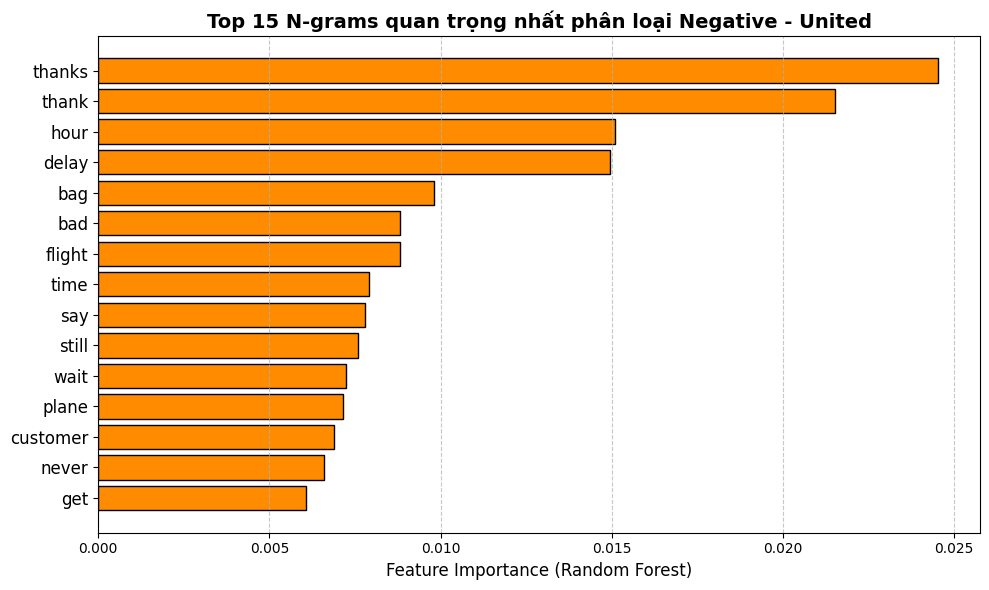

,N-gram,Feature Importance
0,thanks,0.024527
1,thank,0.021517
2,hour,0.015095
3,delay,0.014950
4,bag,0.009815
5,bad,0.008808
6,flight,0.008805
7,time,0.007898
8,say,0.007794
9,still,0.007592



=== PHÂN TÍCH HÃNG AMERICAN AIRLINES ===


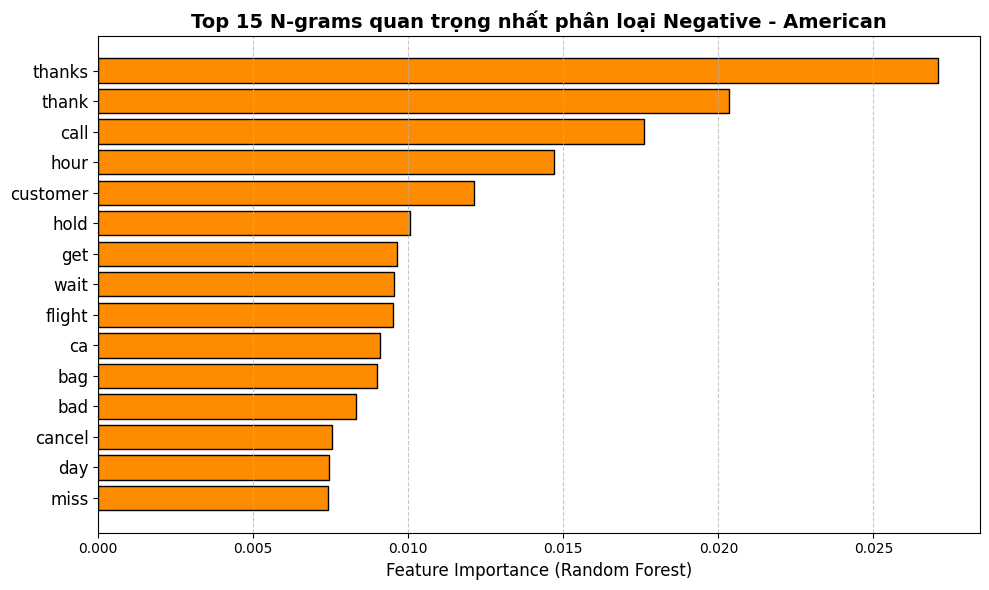

,N-gram,Feature Importance
0,thanks,0.027084
1,thank,0.020360
2,call,0.017600
3,hour,0.014717
4,customer,0.012112
5,hold,0.010071
6,get,0.009640
7,wait,0.009548
8,flight,0.009514
9,ca,0.009080


In [28]:
# Khởi chạy cho United Airlines
print("=== PHÂN TÍCH HÃNG UNITED AIRLINES ===")
united_top_ngrams = plot_top_negative_ngrams_rf(df, 'United', top_n=15)
display(united_top_ngrams)

# Khởi chạy cho American Airlines
print("\n=== PHÂN TÍCH HÃNG AMERICAN AIRLINES ===")
american_top_ngrams = plot_top_negative_ngrams_rf(df, 'American', top_n=15)
display(american_top_ngrams)